# Stage 7: Repeated-seed robustness and business sensitivity

This stage asks whether the Stage 6 findings survive new simulated cohorts and
changes to retention value, treatment cost, and campaign capacity.

The prespecified experiment uses **10 simulation seeds (42–51)**, **20,000
customers per seed**, and **27 business scenarios**. Each seed refits S/T/DR on
14,000 customers, calibrates thresholds on 3,000 independent customers, and
evaluates on the remaining 3,000. Algorithm randomness stays fixed at seed 42.
There are six policies per scenario, for **1,620 policy evaluations** in total.

Run `.venv\Scripts\python.exe scripts/run_stage7.py` to reproduce the complete
experiment and this report. Checkpoints are reused only under the same source,
configuration, and recorded environment fingerprint. This notebook renders the
published experiment tables; it does not silently refit models.

See [methodology and limitations](../docs/stage_7_robustness.md). Poor overlap and
hidden-confounding interventions remain Stage 8 work.

In [1]:
from pathlib import Path
import os
import sys

# Start Jupyter from the repository/notebooks directory, or explicitly set
# CAUSAL_INFERENCE_ROOT when the kernel starts elsewhere.
configured_root = os.environ.get("CAUSAL_INFERENCE_ROOT")
current_directory = Path.cwd().resolve()
candidates = (
    [Path(configured_root).expanduser().resolve()]
    if configured_root
    else [current_directory, *current_directory.parents]
)
PROJECT_ROOT = next(
    (
        candidate for candidate in candidates
        if all(
            (candidate / "src" / filename).is_file()
            for filename in ("causal_learners.py", "policies.py", "simulation.py")
        )
        and (candidate / "notebooks" / "05_robustness_and_sensitivity.ipynb").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Cannot locate the Causal_Inference repository. Start Jupyter from "
        "the project or notebooks directory, or set CAUSAL_INFERENCE_ROOT "
        "to the repository path before running this notebook."
    )

SRC_DIRECTORY = PROJECT_ROOT / "src"
if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from robustness import SCENARIO_COLUMNS, paired_policy_differences, summarize_replicates

sns.set_theme(style="whitegrid", context="notebook")
TABLES = PROJECT_ROOT / "reports" / "tables"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
manifest = json.loads((TABLES / "stage7_manifest.json").read_text(encoding="utf-8"))
effects = pd.read_csv(TABLES / "stage7_cate_by_seed.csv")
policies = pd.read_csv(TABLES / "stage7_policy_by_seed.csv")
diagnostics = pd.read_csv(TABLES / "stage7_diagnostics_by_seed.csv")
paired = pd.read_csv(TABLES / "stage7_paired_by_seed.csv")
policy_summary = pd.read_csv(TABLES / "stage7_policy_summary.csv")
paired_summary = pd.read_csv(TABLES / "stage7_paired_summary.csv")
grid = pd.read_csv(TABLES / "stage7_scenario_grid.csv")
MODEL_ORDER = ["S-learner", "T-learner", "DR-learner"]
POLICY_ORDER = ["Treat nobody", "Random", *MODEL_ORDER, "Oracle"]
SEEDS = manifest["config"]["seeds"]

def baseline(frame):
    return frame[(frame.retention_value == 80) & (frame.treatment_cost == 10) & np.isclose(frame.capacity, 0.2)].copy()

def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / name, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Seeds:", SEEDS)
print("Scenarios:", len(grid), "Policy rows:", len(policies))
print("Experiment fingerprint:", manifest["experiment_fingerprint"])


Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Scenarios: 27 Policy rows: 1620
Experiment fingerprint: bd52a4a6cf35e7197ff1fc47fbec7ed0891ccaca667890fe5f7ad03a448d254d


## 1. Repeated-seed effect estimation

Box plots show the ten seed-level results, with each point representing a new
cohort and split. Model settings are unchanged from Stage 6; no model or seed is
selected based on final evaluation results. The summary SD is between-seed
variability; MCSE is `SD / sqrt(number of seeds)`. Empirical quantiles from ten
seeds are descriptive and should not be interpreted as reliable tail coverage.

,model,metric,replicates,mean,std,mcse,median,minimum,maximum,q025,q975
0,DR-learner,ate_error,10,0.007409,0.005180,0.001638,0.007460,0.000187,0.015456,0.000372,0.015210
1,DR-learner,pehe,10,0.084186,0.004649,0.001470,0.083859,0.079857,0.094985,0.079886,0.093340
2,DR-learner,cate_mae,10,0.065998,0.003849,0.001217,0.065968,0.062164,0.074925,0.062255,0.073505
3,DR-learner,cate_correlation,10,0.747210,0.025020,0.007912,0.744261,0.712375,0.778336,0.713194,0.777747
4,S-learner,ate_error,10,0.055332,0.009501,0.003004,0.056443,0.038816,0.067069,0.038962,0.066270
5,S-learner,pehe,10,0.082562,0.008590,0.002716,0.085221,0.068815,0.091614,0.068896,0.091520
6,S-learner,cate_mae,10,0.063596,0.006951,0.002198,0.065564,0.051519,0.072305,0.051858,0.071683
7,S-learner,cate_correlation,10,0.810514,0.029944,0.009469,0.816806,0.765217,0.857705,0.765350,0.852243
8,T-learner,ate_error,10,0.061851,0.004158,0.001315,0.061469,0.054723,0.071080,0.055769,0.069552
9,T-learner,pehe,10,0.094530,0.004007,0.001267,0.095665,0.088129,0.098894,0.088441,0.098691


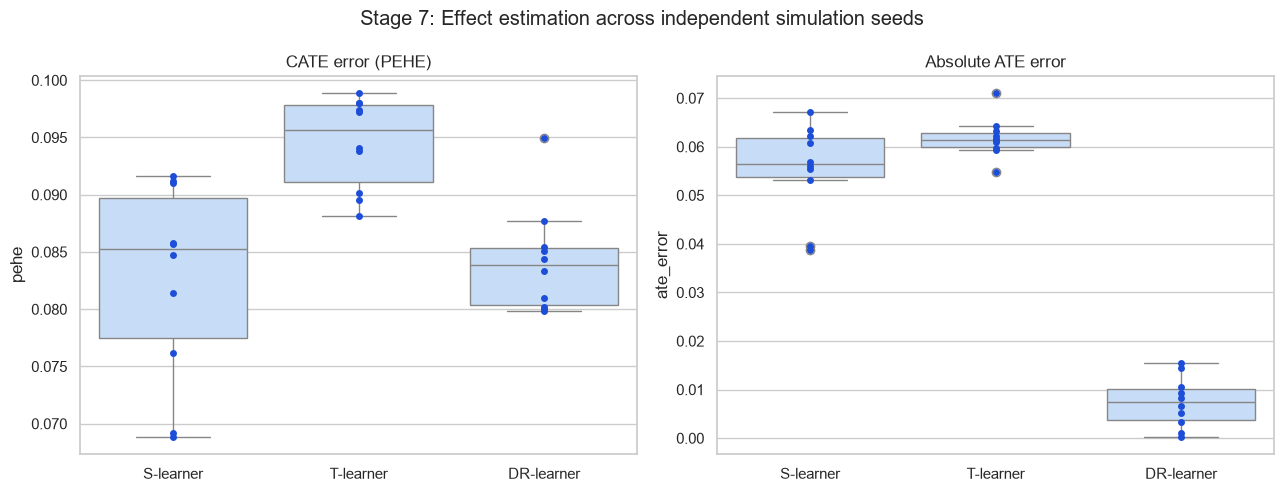

In [3]:
effect_summary = pd.read_csv(TABLES / "stage7_cate_summary.csv")
display(effect_summary)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, metric, title in zip(axes, ["pehe", "ate_error"], ["CATE error (PEHE)", "Absolute ATE error"]):
    sns.boxplot(data=effects, x="model", y=metric, order=MODEL_ORDER, ax=axis, color="#BFDBFE")
    sns.stripplot(data=effects, x="model", y=metric, order=MODEL_ORDER, ax=axis, color="#1D4ED8", jitter=False, size=5)
    axis.set(title=title, xlabel="", ylabel=metric)
fig.suptitle("Stage 7: Effect estimation across independent simulation seeds")
save(fig, "stage7_effect_robustness.png")

## 2. Baseline policy profit and seed-paired comparisons

The baseline remains value $80, cost $10, capacity 20%. Thresholds are calibrated
separately for each learner on calibration covariates. A hard evaluation capacity
cap is enforced without looking at outcomes. Oracle profit is evaluated using
simulation truth only.

Pair policies within the same seed, scenario, and evaluation cohort. Scenarios
share the same predictions and outcomes within a seed and are not independent
replicates. Seed-averaged differences, win counts, and ties describe this
experiment; they do not certify a universally best learner.

,policy,metric,replicates,mean,std,mcse
546,DR-learner,incremental_profit,10,6954.557015,368.419537,116.504487
547,DR-learner,profit_per_customer,10,2.318186,0.122807,0.038835
548,DR-learner,regret_vs_oracle,10,1765.495244,307.671541,97.294284
549,DR-learner,oracle_profit_captured,10,0.797347,0.036155,0.011433
550,DR-learner,treatment_rate,10,0.194667,0.007284,0.002304
551,DR-learner,dr_incremental_profit,10,5973.429916,2566.512355,811.602468
552,DR-learner,observational_estimation_error,10,-981.127098,2385.860997,754.475493
553,Oracle,incremental_profit,10,8720.052259,122.435742,38.717581
554,Oracle,profit_per_customer,10,2.906684,0.040812,0.012906
555,Oracle,regret_vs_oracle,10,0.000000,0.000000,0.000000


,comparison,metric,replicates,mean,std,mcse
117,DR-learner minus S-learner,profit_difference,10,-133.200728,254.403751,80.449530
118,DR-learner minus S-learner,left_wins,10,0.300000,0.483046,0.152753
119,DR-learner minus S-learner,tie,10,0.000000,0.000000,0.000000
120,DR-learner minus T-learner,profit_difference,10,323.708294,312.910243,98.950907
121,DR-learner minus T-learner,left_wins,10,0.900000,0.316228,0.100000
122,DR-learner minus T-learner,tie,10,0.000000,0.000000,0.000000
123,S-learner minus T-learner,profit_difference,10,456.909023,255.664800,80.848309
124,S-learner minus T-learner,left_wins,10,0.900000,0.316228,0.100000
125,S-learner minus T-learner,tie,10,0.000000,0.000000,0.000000


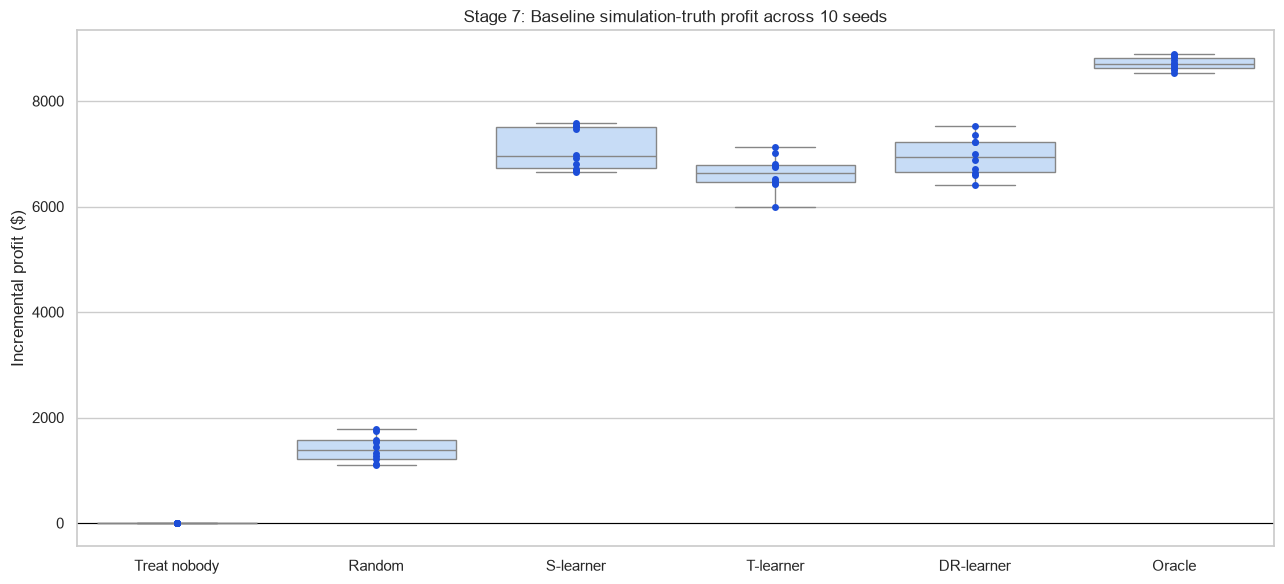

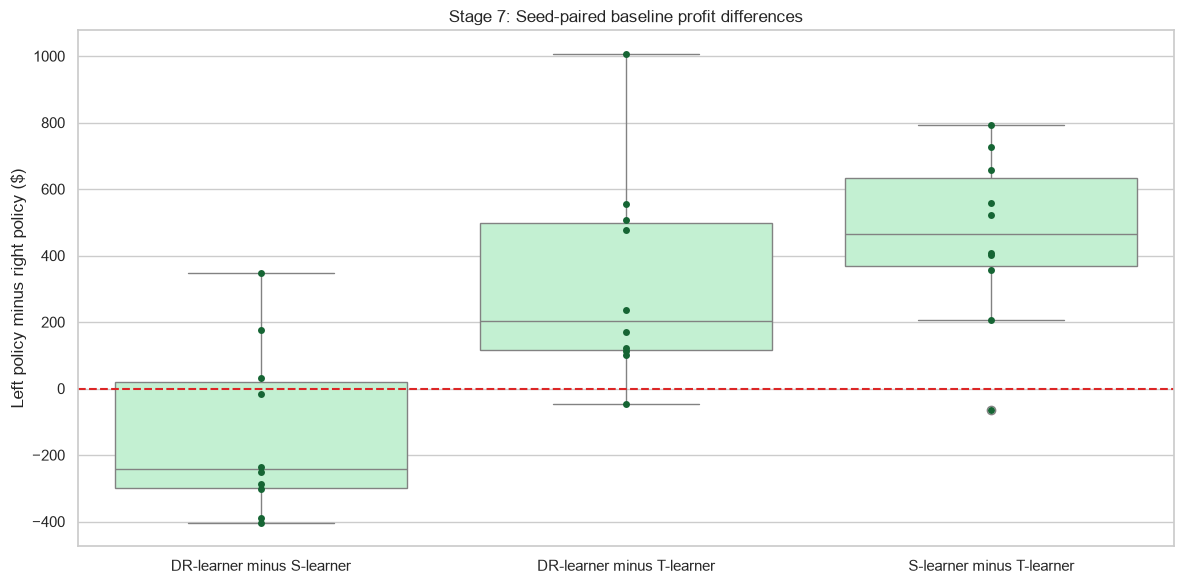

In [4]:
base = baseline(policies)
base_paired = baseline(paired)
display(baseline(policy_summary)[["policy", "metric", "replicates", "mean", "std", "mcse"]])
display(baseline(paired_summary)[["comparison", "metric", "replicates", "mean", "std", "mcse"]])
fig, axis = plt.subplots(figsize=(13, 6))
sns.boxplot(data=base, x="policy", y="incremental_profit", order=POLICY_ORDER, color="#BFDBFE", ax=axis)
sns.stripplot(data=base, x="policy", y="incremental_profit", order=POLICY_ORDER, color="#1D4ED8", jitter=False, size=5, ax=axis)
axis.axhline(0, color="black", linewidth=0.8)
axis.set(title=f"Stage 7: Baseline simulation-truth profit across {len(SEEDS)} seeds", xlabel="", ylabel="Incremental profit ($)")
save(fig, "stage7_baseline_profit_robustness.png")
fig, axis = plt.subplots(figsize=(12, 6))
order = ["DR-learner minus S-learner", "DR-learner minus T-learner", "S-learner minus T-learner"]
sns.boxplot(data=base_paired, x="comparison", y="profit_difference", order=order, color="#BBF7D0", ax=axis)
sns.stripplot(data=base_paired, x="comparison", y="profit_difference", order=order, color="#166534", jitter=False, ax=axis)
axis.axhline(0, color="#DC2626", linestyle="--")
axis.set(title="Stage 7: Seed-paired baseline profit differences", xlabel="", ylabel="Left policy minus right policy ($)")
save(fig, "stage7_paired_policy_differences.png")

## 3. Retention value and treatment cost sensitivity

Full factorial values are $40/$80/$120, costs $5/$10/$20, capacities
10%/20%/30%. Reuse the fitted CATE predictions, but recalibrate the economic
threshold separately for every prespecified scenario. Only economic assumptions
change: increasing the cost does not change the simulated treatment effect or
the offer itself. Effects of changing the physical offer need a new simulator.

Heat maps show average simulation-truth profit at 20% capacity. Values and costs
are not tuned on evaluation outcomes. Profits may be negative when a model
incorrectly predicts profitable customers. Oracle-profit ratios are missing
when oracle profit is zero, rather than being forced to zero or divided by zero.

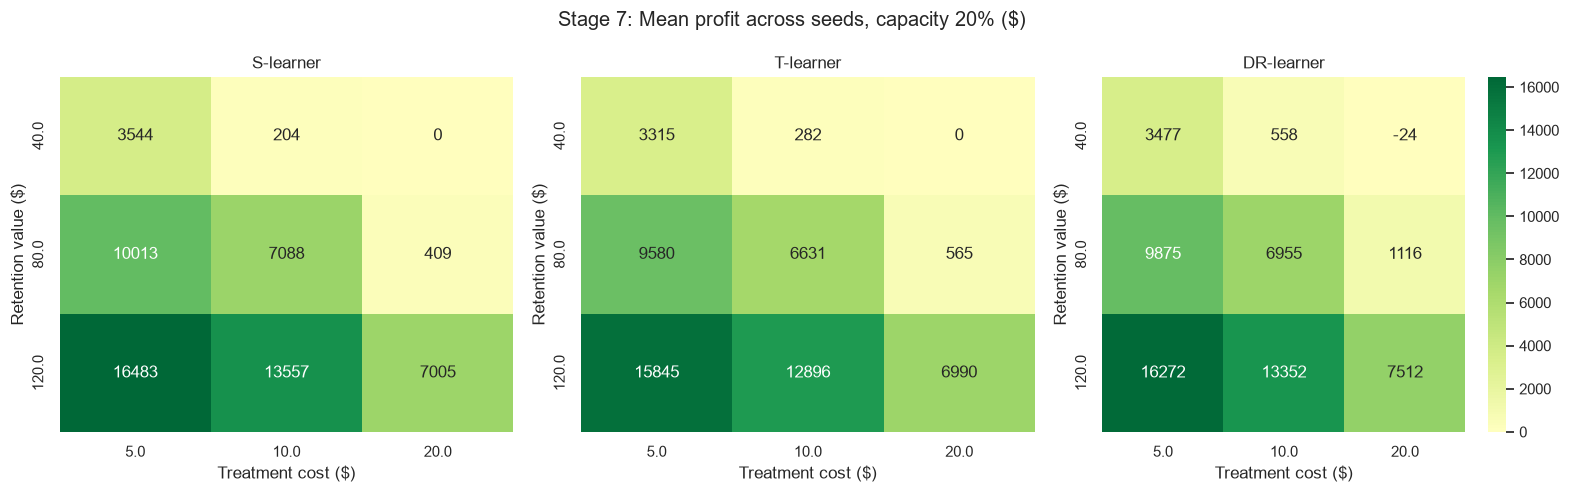

In [5]:
subset = policies[np.isclose(policies.capacity, 0.2) & policies.policy.isin(MODEL_ORDER)]
means = subset.groupby(["policy", "retention_value", "treatment_cost"]).incremental_profit.mean()
vmin, vmax = min(0, means.min()), max(0, means.max())
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for axis, name in zip(axes, MODEL_ORDER):
    table = means.loc[name].unstack("treatment_cost").sort_index()
    sns.heatmap(table, annot=True, fmt=".0f", cmap="RdYlGn", vmin=vmin, vmax=vmax,
                center=0, ax=axis, cbar=(name == MODEL_ORDER[-1]))
    axis.set(title=name, xlabel="Treatment cost ($)", ylabel="Retention value ($)")
fig.suptitle("Stage 7: Mean profit across seeds, capacity 20% ($)")
save(fig, "stage7_value_cost_sensitivity.png")

## 4. Campaign capacity sensitivity

Lines show mean profit and shading shows **one between-seed SD**, not a
confidence interval. All three capacity settings use the same independently
fitted predictions within each seed, but each has its own calibration threshold.
Treat-none remains feasible at all settings; fixed-capacity random targeting may
be unprofitable under adverse economics.

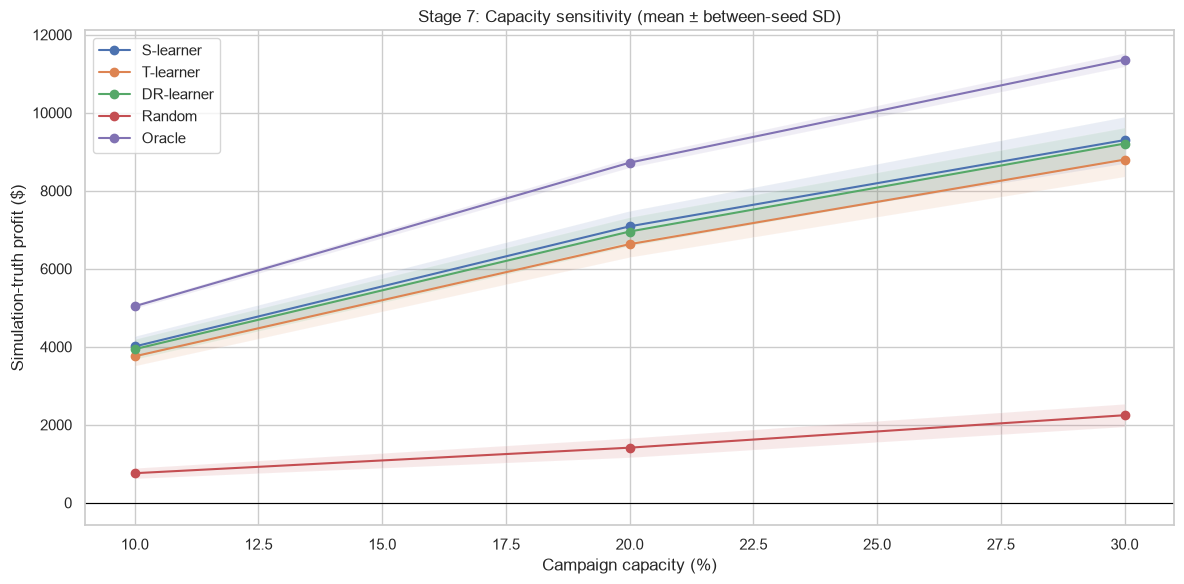

In [6]:
capacity_rows = policies[(policies.retention_value == 80) & (policies.treatment_cost == 10)]
fig, axis = plt.subplots(figsize=(12, 6))
for name in [*MODEL_ORDER, "Random", "Oracle"]:
    summary = capacity_rows[capacity_rows.policy == name].groupby("capacity").incremental_profit.agg(["mean", "std"])
    x = summary.index.to_numpy()*100
    axis.plot(x, summary["mean"], marker="o", label=name)
    axis.fill_between(x, summary["mean"]-summary["std"], summary["mean"]+summary["std"], alpha=0.12)
axis.axhline(0, color="black", linewidth=0.8)
axis.set(title="Stage 7: Capacity sensitivity (mean ± between-seed SD)", xlabel="Campaign capacity (%)", ylabel="Simulation-truth profit ($)")
axis.legend()
save(fig, "stage7_capacity_sensitivity.png")

## 5. Observational evaluation uncertainty across seeds

AIPW estimates are compared with simulation truth on the same final evaluation
cohorts. Error here means observational estimated profit minus true expected
profit. The individual Stage 6 pointwise intervals remain approximate, omit
model-fitting uncertainty, and do not certify the cohort-wide allocation rule.
This stage reports empirical estimation error, not nominal interval coverage.
It also does not repair unobserved confounding or positivity violations.

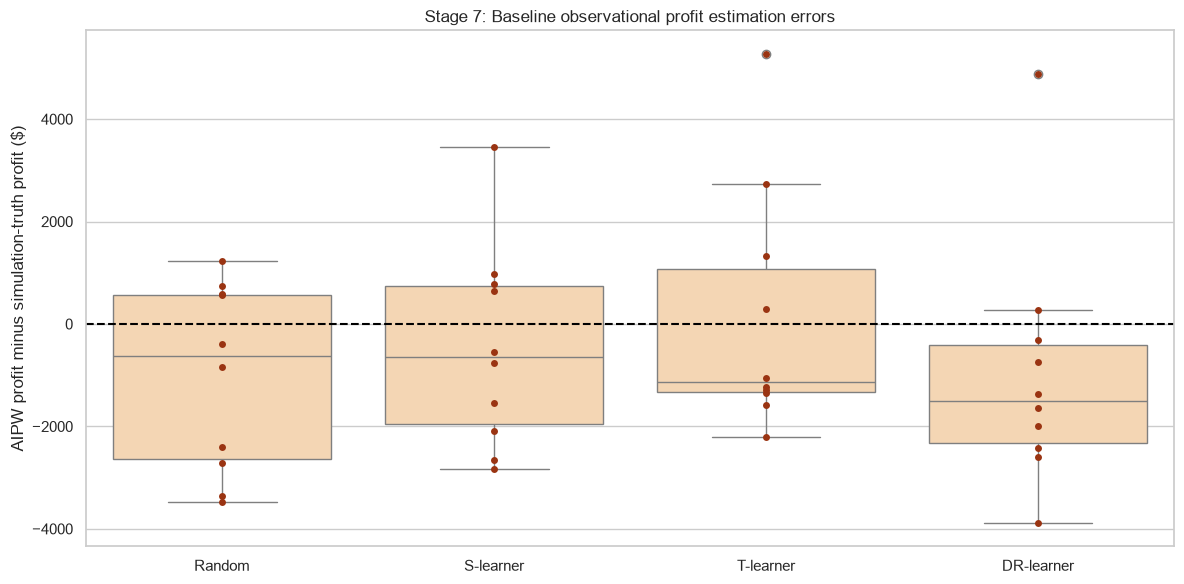

,seed,training_customers,calibration_customers,evaluation_customers,training_treatment_rate,evaluation_treatment_rate,min_propensity,max_propensity,propensity_clipped_fraction
0,42,14000,3000,3000,0.299929,0.293333,0.043409,0.840356,0.000667
1,43,14000,3000,3000,0.303786,0.289667,0.051170,0.789153,0.000000
2,44,14000,3000,3000,0.291000,0.306667,0.047940,0.821909,0.000333
3,45,14000,3000,3000,0.307286,0.288333,0.051074,0.768029,0.000000
4,46,14000,3000,3000,0.298643,0.301000,0.045428,0.760448,0.000667
5,47,14000,3000,3000,0.302143,0.301333,0.038672,0.803255,0.001000
6,48,14000,3000,3000,0.301143,0.301667,0.037575,0.788934,0.001333
7,49,14000,3000,3000,0.291643,0.301667,0.043277,0.762979,0.001000
8,50,14000,3000,3000,0.299214,0.285667,0.047958,0.750657,0.000333
9,51,14000,3000,3000,0.293571,0.306333,0.034791,0.785181,0.001667


Learned-policy capacity cap activation share: 0.362962962962963


In [7]:
fig, axis = plt.subplots(figsize=(12, 6))
obs = base[base.policy.isin(["Random", *MODEL_ORDER])]
sns.boxplot(data=obs, x="policy", y="observational_estimation_error", order=["Random", *MODEL_ORDER], color="#FED7AA", ax=axis)
sns.stripplot(data=obs, x="policy", y="observational_estimation_error", order=["Random", *MODEL_ORDER], color="#9A3412", jitter=False, ax=axis)
axis.axhline(0, color="black", linestyle="--")
axis.set(title="Stage 7: Baseline observational profit estimation errors", xlabel="", ylabel="AIPW profit minus simulation-truth profit ($)")
save(fig, "stage7_observational_error_robustness.png")
display(diagnostics)
print("Learned-policy capacity cap activation share:", policies[policies.policy.isin(MODEL_ORDER)].capacity_cap_active.mean())

## 6. Completion checks

Every seed is retained, including unfavorable policies and zero-profit oracle
scenarios. Summaries aggregate seeds separately inside each scenario. Ten seeds
support an initial robustness study, not a reliable statement about extreme
simulation tails, all business settings, or real customers.

In [8]:
n = len(SEEDS)
assert set(effects.seed) == set(SEEDS) == set(policies.seed) == set(diagnostics.seed)
assert len(effects) == 3*n and len(policies) == 6*n*len(grid)
assert not effects.duplicated(["seed", "model"]).any()
assert not policies.duplicated(["seed", *SCENARIO_COLUMNS, "policy"]).any()
assert (policies.groupby(["seed", *SCENARIO_COLUMNS]).size() == 6).all()
assert (policies.groupby("seed").size() == 6*len(grid)).all()
assert np.isfinite(effects.select_dtypes(include="number")).all().all()
assert np.isfinite(policies[["incremental_profit", "regret_vs_oracle", "profit_per_customer"]]).all().all()
assert (policies.regret_vs_oracle >= -1e-7).all()
assert policies.capacity_feasible.all()
assert ((policies.treated_count / diagnostics.evaluation_customers.iloc[0]) <= policies.capacity+1e-12).all()
assert (policies[policies.oracle_profit == 0].oracle_profit_captured.isna()).all()
assert (policies[policies.policy == "Treat nobody"].incremental_profit == 0).all()
assert (policies[policies.policy == "Treat nobody"].dr_incremental_profit == 0).all()
recomputed = paired_policy_differences(policies)
pd.testing.assert_frame_equal(paired, recomputed, check_dtype=False, atol=1e-7)
expected = ["stage7_effect_robustness.png", "stage7_baseline_profit_robustness.png",
            "stage7_paired_policy_differences.png", "stage7_value_cost_sensitivity.png",
            "stage7_capacity_sensitivity.png", "stage7_observational_error_robustness.png"]
assert all((FIGURES / name).is_file() and (FIGURES / name).stat().st_size > 0 for name in expected)
for filename, rows in manifest["rows"].items():
    assert len(pd.read_csv(TABLES / filename)) == rows
print(f"Stage 7 checks passed: {n} seeds, {len(grid)} scenarios, {len(policies)} policy results, six saved figures.")

Stage 7 checks passed: 10 seeds, 27 scenarios, 1620 policy results, six saved figures.
